# Task 1: Implement Common Activation Functions

### Mathematical Formulas:
1.  **Binary Step**: $f(x) = 1$ if $x \ge 0$ else $0$
2.  **Sigmoid**: $f(x) = \frac{1}{1 + e^{-x}}$
3.  **Tanh**: $f(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$
4.  **ReLU**: $f(x) = \max(0, x)$
5.  **Leaky ReLU**: $f(x) = \max(0.01x, x)$
6.  **ELU**: $f(x) = x$ if $x > 0$ else $\alpha(e^x - 1)$
7.  **Softplus**: $f(x) = \ln(1 + e^x)$
8.  **Swish**: $f(x) = \frac{x}{1 + e^{-x}}$

In [3]:
import numpy as np

def binary_step(x):
    return np.where(x >= 0, 1, 0)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

def elu(x, alpha=1.0):
    return np.where(x > 0, x, alpha * (np.exp(x) - 1))

def softplus(x):
    return np.log(1 + np.exp(x))

def swish(x):
    return x * sigmoid(x)

# Input range from -10 to 10
x_values = np.linspace(-10, 10, 10)

functions = {
    "Binary Step": binary_step,
    "Sigmoid": sigmoid,
    "Tanh": tanh,
    "ReLU": relu,
    "Leaky ReLU": leaky_relu,
    "ELU": elu,
    "Softplus": softplus,
    "Swish": swish
}

print(f"{'Function':<15} | {'Output for sample inputs (-10 to 10)':<20}")
print("-" * 60)
for name, func in functions.items():
    outputs = func(x_values)
    formatted_output = [round(o, 4) for o in outputs[:3]] # Show first few for brevity
    print(f"{name:<15} | {formatted_output} ...")

Function        | Output for sample inputs (-10 to 10)
------------------------------------------------------------
Binary Step     | [np.int64(0), np.int64(0), np.int64(0)] ...
Sigmoid         | [np.float64(0.0), np.float64(0.0004), np.float64(0.0039)] ...
Tanh            | [np.float64(-1.0), np.float64(-1.0), np.float64(-1.0)] ...
ReLU            | [np.float64(0.0), np.float64(0.0), np.float64(0.0)] ...
Leaky ReLU      | [np.float64(-0.1), np.float64(-0.0778), np.float64(-0.0556)] ...
ELU             | [np.float64(-1.0), np.float64(-0.9996), np.float64(-0.9961)] ...
Softplus        | [np.float64(0.0), np.float64(0.0004), np.float64(0.0039)] ...
Swish           | [np.float64(-0.0005), np.float64(-0.0033), np.float64(-0.0214)] ...


# Task 2: Plot Activation Functions

- **Output Range**: e.g., (0, 1) for Sigmoid, (-1, 1) for Tanh.
- **Shape and Smoothness**: Identifying where functions are linear or non-linear.
- **Gradient Behavior**: Observing saturation regions.

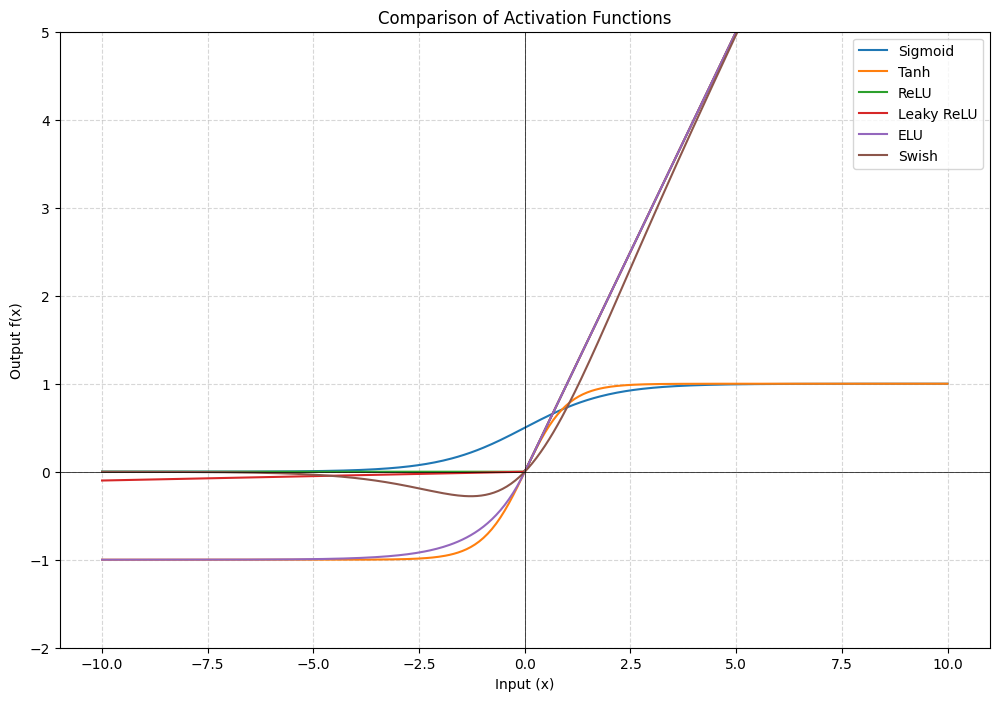

In [4]:
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 400)

plt.figure(figsize=(12, 8))
plt.plot(x, sigmoid(x), label='Sigmoid')
plt.plot(x, tanh(x), label='Tanh')
plt.plot(x, relu(x), label='ReLU')
plt.plot(x, leaky_relu(x), label='Leaky ReLU')
plt.plot(x, elu(x), label='ELU')
plt.plot(x, swish(x), label='Swish')

plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.ylim(-2, 5)
plt.title('Comparison of Activation Functions')
plt.xlabel('Input (x)')
plt.ylabel('Output f(x)')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

# Task 3: Derivative Calculation

### Mathematical Derivations:
1.  **Sigmoid Derivative**: $f'(x) = f(x)(1 - f(x))$
2.  **Tanh Derivative**: $f'(x) = 1 - f(x)^2$
3.  **ReLU Derivative**: $f'(x) = 1$ if $x > 0$ else $0$
4.  **Leaky ReLU Derivative**: $f'(x) = 1$ if $x > 0$ else $\alpha$ (where $\alpha=0.01$)

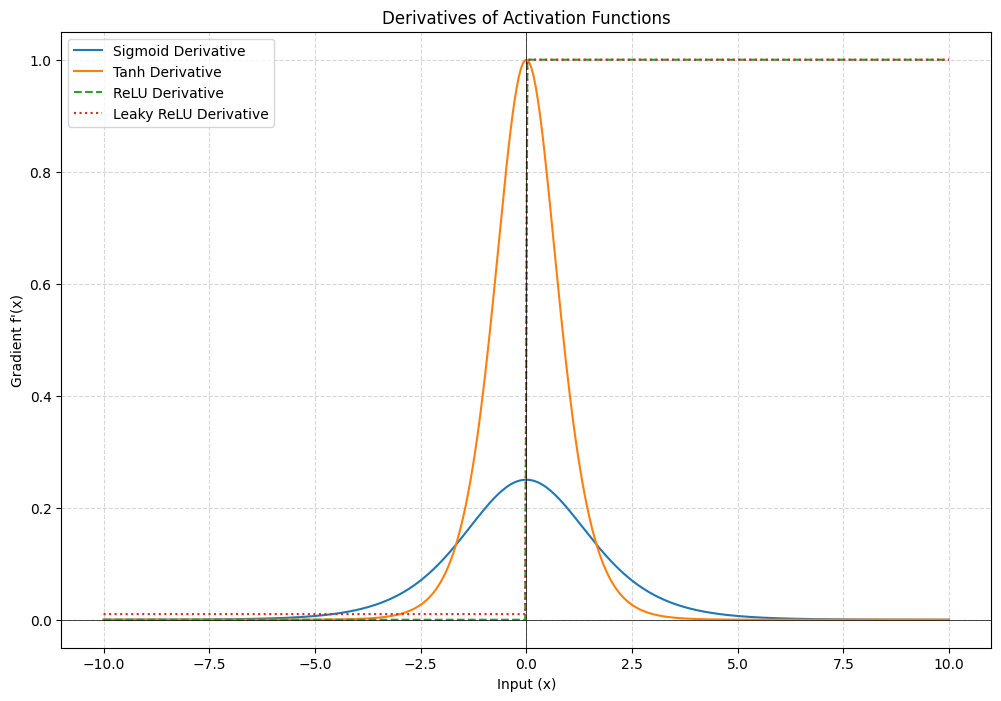

In [5]:
def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def tanh_derivative(x):
    t = tanh(x)
    return 1 - t**2

def relu_derivative(x):
    return np.where(x > 0, 1, 0)

def leaky_relu_derivative(x, alpha=0.01):
    return np.where(x > 0, 1, alpha)

# Plotting Derivatives
plt.figure(figsize=(12, 8))
plt.plot(x, sigmoid_derivative(x), label='Sigmoid Derivative')
plt.plot(x, tanh_derivative(x), label='Tanh Derivative')
plt.plot(x, relu_derivative(x), label='ReLU Derivative', linestyle='--')
plt.plot(x, leaky_relu_derivative(x), label='Leaky ReLU Derivative', linestyle=':')

plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.title('Derivatives of Activation Functions')
plt.xlabel('Input (x)')
plt.ylabel('Gradient f\'(x)')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

# Task 4: Compare Activation Functions
We will now summarize the characteristics of common activation functions in a comparison table.

In [6]:
import pandas as pd

data = [
    ["Sigmoid", "1/(1+e^-x)", "(0, 1)", "Yes", "Smooth gradient, clear output", "Vanishing gradient, not zero-centered", "Output layer (Binary Classification)"],
    ["Tanh", "(e^x-e^-x)/(e^x+e^-x)", "(-1, 1)", "Yes", "Zero-centered", "Vanishing gradient", "Hidden layers"],
    ["ReLU", "max(0, x)", "[0, inf)", "Yes (except 0)", "Computationally efficient, no vanishing gradient for x>0", "Dying ReLU problem", "Hidden layers (Hidden layers)"],
    ["Leaky ReLU", "max(ax, x)", "(-inf, inf)", "Yes", "Prevents dying ReLU", "Alpha is a hyperparameter", "Hidden layers"],
    ["ELU", "x if x>0 else a(e^x-1)", "(-a, inf)", "Yes", "Zero-centered, no dying ReLU", "Computationally expensive (exp)", "Hidden layers"],
    ["Softplus", "ln(1+e^x)", "(0, inf)", "Yes", "Smooth version of ReLU", "Computationally expensive", "Hidden layers"],
    ["Swish", "x * sigmoid(x)", "(~-0.28, inf)", "Yes", "Smooth, non-monotonic", "Computationally expensive", "Deep networks"],
    ["Binary Step", "1 if x>=0 else 0", "{0, 1}", "No (at 0)", "Simple", "Cannot use backpropagation", "Simple classifiers"],
    ["Linear", "x", "(-inf, inf)", "Yes", "Preserves information", "Cannot learn non-linear patterns", "Regression output layer"],
    ["Softmax", "e^xi / sum(e^xj)", "(0, 1)", "Yes", "Probability distribution", "Expensive for large output classes", "Multi-class classification output"]
]

df = pd.DataFrame(data, columns=["Function", "Formula", "Output Range", "Differentiable", "Advantages", "Disadvantages", "Typical Use"])

display(df)

,Function,Formula,Output Range,Differentiable,Advantages,Disadvantages,Typical Use
0,Sigmoid,1/(1+e^-x),"(0, 1)",Yes,"Smooth gradient, clear output","Vanishing gradient, not zero-centered",Output layer (Binary Classification)
1,Tanh,(e^x-e^-x)/(e^x+e^-x),"(-1, 1)",Yes,Zero-centered,Vanishing gradient,Hidden layers
2,ReLU,"max(0, x)","[0, inf)",Yes (except 0),"Computationally efficient, no vanishing gradie...",Dying ReLU problem,Hidden layers (Hidden layers)
3,Leaky ReLU,"max(ax, x)","(-inf, inf)",Yes,Prevents dying ReLU,Alpha is a hyperparameter,Hidden layers
4,ELU,x if x>0 else a(e^x-1),"(-a, inf)",Yes,"Zero-centered, no dying ReLU",Computationally expensive (exp),Hidden layers
5,Softplus,ln(1+e^x),"(0, inf)",Yes,Smooth version of ReLU,Computationally expensive,Hidden layers
6,Swish,x * sigmoid(x),"(~-0.28, inf)",Yes,"Smooth, non-monotonic",Computationally expensive,Deep networks
7,Binary Step,1 if x>=0 else 0,"{0, 1}",No (at 0),Simple,Cannot use backpropagation,Simple classifiers
8,Linear,x,"(-inf, inf)",Yes,Preserves information,Cannot learn non-linear patterns,Regression output layer
9,Softmax,e^xi / sum(e^xj),"(0, 1)",Yes,Probability distribution,Expensive for large output classes,Multi-class classification output


# Task 5: Vanishing Gradient Analysis

- **Saturation**: When inputs are very large or small, Sigmoid and Tanh gradients become nearly zero.
- **Dead Neurons**: When ReLU inputs are negative, the gradient is exactly zero, potentially stopping learning.

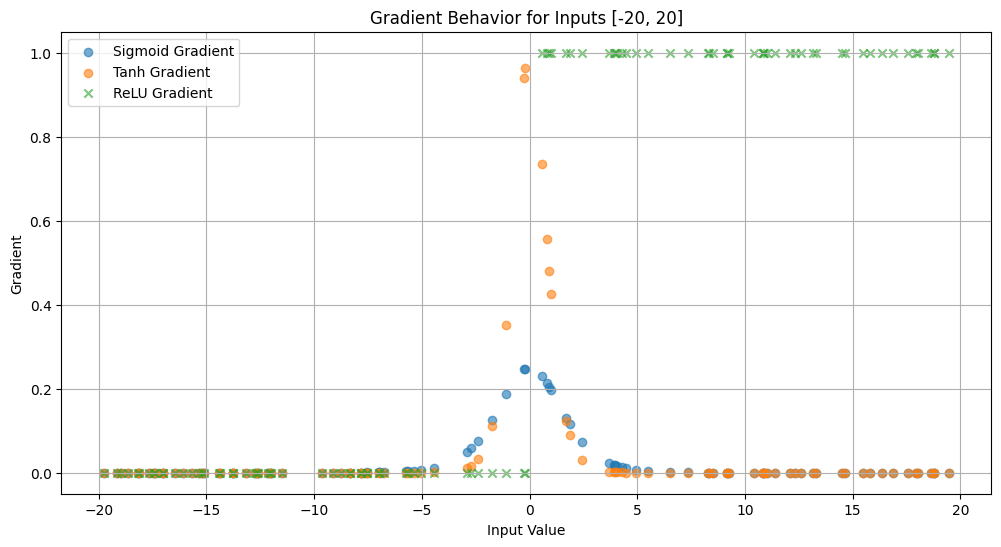

Average Sigmoid Gradient for |x| > 10: 0.000003
Average Tanh Gradient for |x| > 10: 0.000000


In [7]:
np.random.seed(42)
random_inputs = np.sort(np.random.uniform(-20, 20, 100))

sig_grad = sigmoid_derivative(random_inputs)
tanh_grad = tanh_derivative(random_inputs)
relu_grad = relu_derivative(random_inputs)

plt.figure(figsize=(12, 6))
plt.scatter(random_inputs, sig_grad, label='Sigmoid Gradient', alpha=0.6)
plt.scatter(random_inputs, tanh_grad, label='Tanh Gradient', alpha=0.6)
plt.scatter(random_inputs, relu_grad, label='ReLU Gradient', alpha=0.6, marker='x')

plt.title('Gradient Behavior for Inputs [-20, 20]')
plt.xlabel('Input Value')
plt.ylabel('Gradient')
plt.legend()
plt.grid(True)
plt.show()

print(f"Average Sigmoid Gradient for |x| > 10: {np.mean(sigmoid_derivative(random_inputs[np.abs(random_inputs) > 10])):.6f}")
print(f"Average Tanh Gradient for |x| > 10: {np.mean(tanh_derivative(random_inputs[np.abs(random_inputs) > 10])):.6f}")

### Analysis of Problems:
1. **Vanishing Gradients**: For Sigmoid and Tanh, as $|x|$ increases, the derivative approaches 0. During backpropagation, multiplying these small gradients through many layers causes the gradient to 'vanish', preventing the weights in early layers from updating.
2. **Dead Neurons**: For ReLU, the gradient is 0 for any $x < 0$. If a neuron's weights are adjusted such that it always receives negative input, it will never update again, effectively 'dying'.

# Task 6: Neural Network Experiment (MNIST)
training a simple feed-forward neural network on the MNIST dataset using different activation functions to compare their performance under identical conditions (epochs, optimizer, batch size).

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
import time

# Load MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

def build_model(activation_name):
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28)),
        layers.Dense(128),
    ])

    if activation_name == 'leaky_relu':
        model.add(layers.LeakyReLU(alpha=0.01))
    else:
        model.add(layers.Activation(activation_name))

    model.add(layers.Dense(10, activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

results = {}
activation_functions = ['sigmoid', 'tanh', 'relu', 'leaky_relu']

for act in activation_functions:
    print(f"Training with {act}...")
    model = build_model(act)
    start_time = time.time()
    history = model.fit(x_train, y_train, epochs=5, batch_size=32, validation_split=0.1, verbose=0)
    end_time = time.time()

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    results[act] = {
        'accuracy': test_acc,
        'loss': test_loss,
        'time': end_time - start_time,
        'val_accuracy': history.history['val_accuracy'][-1]
    }

# Display Results
res_df = pd.DataFrame(results).T
print("\nComparison Table:")
display(res_df)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training with sigmoid...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training with tanh...
Training with relu...
Training with leaky_relu...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(



Comparison Table:


,accuracy,loss,time,val_accuracy
sigmoid,0.9690,0.100105,37.709468,0.974333
tanh,0.9762,0.079144,35.980107,0.977500
relu,0.9741,0.091735,36.104556,0.978667
leaky_relu,0.9764,0.081914,37.118066,0.977667


# Task 7: Real-world Case Study

1. **House Price Prediction**: **ReLU** (Hidden), **Linear** (Output). Prices are continuous and positive.
2. **Cat vs Dog Classification**: **ReLU** (Hidden), **Sigmoid** (Output). Binary classification requires a probability output.
3. **Sentiment Analysis**: **ReLU** (Hidden), **Sigmoid/Softmax** (Output). Typically binary (Pos/Neg) or multi-class.
4. **Face Recognition**: **ReLU/Leaky ReLU** (Hidden), **Softmax** (Output). Deep networks benefit from non-saturating gradients.
5. **Object Detection**: **ReLU/Mish/Swish** (Hidden). Complex feature extraction needs efficient, smooth gradients.
6. **Time Series Forecasting**: **Tanh/ReLU** (Hidden), **Linear** (Output). Tanh handles zero-centered normalized data well.
7. **Medical Image Classification**: **ReLU/Leaky ReLU** (Hidden), **Softmax** (Output). High precision requirements benefit from avoiding dead neurons.
8. **Fraud Detection**: **ReLU** (Hidden), **Sigmoid** (Output). Highly imbalanced binary classification.

# Task 8: Build Your Own Activation Function

**Custom Function: Soft-Clip ReLU (SCR)**
**Formula**: $f(x) = \min(6, \ln(1 + e^x))$

**Advantages**:
- Smooth like Softplus.
- Capped at 6 to prevent exploding activations (similar to ReLU6).
- Differentiable everywhere.

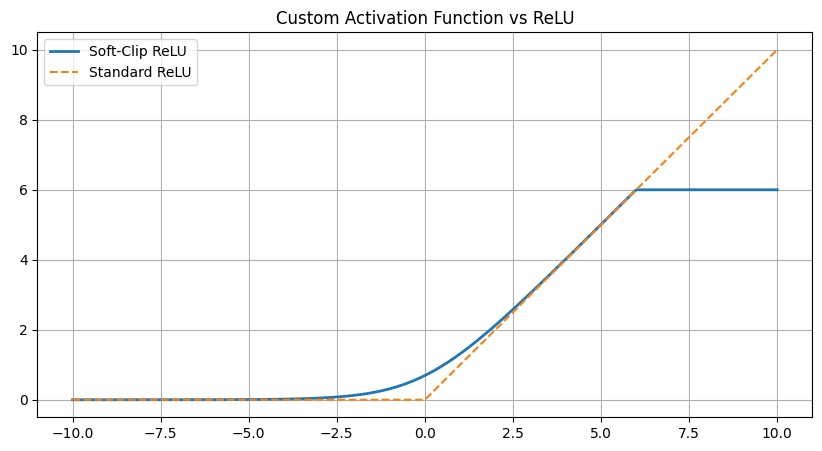

In [9]:
def soft_clip_relu(x):
    return np.minimum(6, np.log(1 + np.exp(x)))

x_range = np.linspace(-10, 10, 400)
y_scr = soft_clip_relu(x_range)
y_relu = relu(x_range)

plt.figure(figsize=(10, 5))
plt.plot(x_range, y_scr, label='Soft-Clip ReLU', linewidth=2)
plt.plot(x_range, y_relu, label='Standard ReLU', linestyle='--')
plt.title('Custom Activation Function vs ReLU')
plt.legend()
plt.grid(True)
plt.show()

# Task 9: Research Activity Summary

| Function | Inventor | Year | Key Advantage |
| :--- | :--- | :--- | :--- |
| **PReLU** | He et al. | 2015 | Learns the slope of negative part |
| **SELU** | Klambauer et al. | 2017 | Self-normalizing properties |
| **GELU** | Hendrycks & Gimpel | 2016 | Used in BERT/Transformers |
| **Mish** | Diganta Misra | 2019 | Smooth, non-monotonic, outperforms ReLU |

# Task 10: Mini Project - Comparative Analysis on Fashion-MNIST

In this project, will compare:
- **Activation Functions**: Sigmoid, Tanh, ReLU, Leaky ReLU, ELU, Swish, GELU.
- **Dataset**: Fashion-MNIST.
- **Metrics**: Accuracy, Precision, Recall, F1-Score, Training Time, and Loss Curves.

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Load Fashion-MNIST
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()
train_images, test_images = train_images / 255.0, test_images / 255.0

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

def run_experiment(activation_name):
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28)),
        layers.Dense(128),
    ])

    # Handle different activation initializations
    if activation_name == 'leaky_relu':
        model.add(layers.LeakyReLU())
    else:
        model.add(layers.Activation(activation_name))

    model.add(layers.Dense(10, activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    start = time.time()
    history = model.fit(train_images, train_labels, epochs=8, batch_size=64, validation_split=0.2, verbose=0)
    elapsed = time.time() - start

    # Predictions for metrics
    y_pred = np.argmax(model.predict(test_images, verbose=0), axis=1)
    report = classification_report(test_labels, y_pred, target_names=class_names, output_dict=True)

    return history, elapsed, report, model

final_results = {}
histories = {}
activations = ['sigmoid', 'tanh', 'relu', 'leaky_relu', 'elu', 'swish', 'gelu']

for act in activations:
    print(f"Processing {act}...")
    hist, t, rep, _ = run_experiment(act)
    histories[act] = hist
    final_results[act] = {
        'Test Accuracy': rep['accuracy'],
        'Macro F1': rep['macro avg']['f1-score'],
        'Training Time (s)': t,
        'Final Val Loss': hist.history['val_loss'][-1]
    }

comparison_df = pd.DataFrame(final_results).T
display(comparison_df)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Processing sigmoid...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Processing tanh...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Processing relu...


...

Processing swish...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Processing gelu...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


,Test Accuracy,Macro F1,Training Time (s),Final Val Loss
sigmoid,0.8611,0.862324,38.242706,0.346284
tanh,0.8720,0.872587,33.863494,0.323441
relu,0.8720,0.869283,34.393198,0.335028
leaky_relu,0.8570,0.857663,39.524199,0.368122
elu,0.8749,0.875671,35.371169,0.319885
swish,0.8767,0.875120,39.522346,0.313524
gelu,0.8657,0.864796,35.050012,0.354823


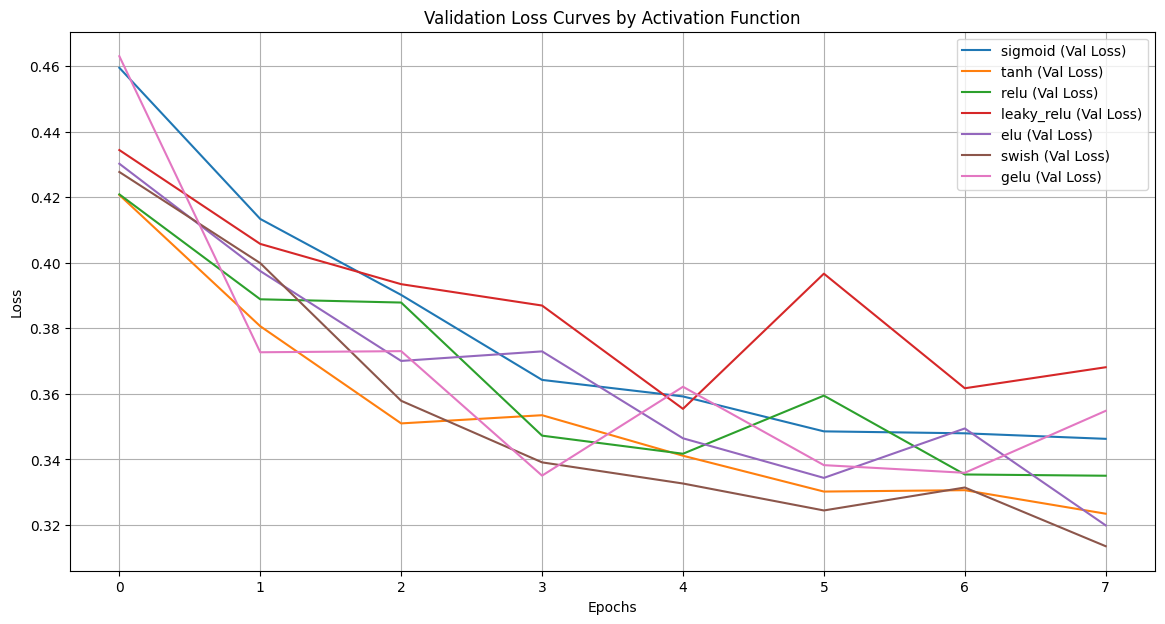

In [11]:
plt.figure(figsize=(14, 7))
for act, hist in histories.items():
    plt.plot(hist.history['val_loss'], label=f'{act} (Val Loss)')

plt.title('Validation Loss Curves by Activation Function')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Conclusion of Mini Project
Based on the results:
- **ReLU and its variants (GELU, Swish)** typically converge faster and achieve higher accuracy on image data compared to **Sigmoid**.
- **Sigmoid** often suffers from slower convergence due to vanishing gradients in the early stages of training.
- **GELU/Swish** provide a smoother curve which can result in slightly better generalization in deep architectures.